# 14 — LPT density: MAP estimation (dev notebook)

A clean, dev-oriented notebook for debugging the **minimization** itself: a joint MAP reconstruction of $(\Omega_c,\sigma_8)$ and the $\mathrm{MESH}^3$ initial-condition field on a 1LPT → spherical galaxy-overdensity mock (2 source planes, seed 0), minimized with **cadre** (`optax_lbfgs`). No MCMC, and no Laplace machinery beyond a cheap 2×2 curvature of the conditioned potential. Headless: `uv run --no-sync papermill 14-LPT-MAP-Estimation.ipynb 14-LPT-MAP-Estimation.ipynb --cwd .`

## 1. Setup

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"  # float32 => NaN/chaotic IC gradients
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORMS", "cuda,cpu")
os.environ["HF_DATASETS_OFFLINE"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

import time

import cadre
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.special import ndtr, ndtri
from numpyro.handlers import condition, seed, trace
from numpyro.infer.util import initialize_model

import jax_fli as jfli
from jax_fli.initial import interpolate_initial_conditions

jax.config.update("jax_enable_x64", True)

# --- knobs: smoke-test scale; bump for production ---
MESH = 8  # production: 256
NSIDE = 8  # production: = MESH
MAP_MAX_ITER = 2  # production: 500+
INIT_NOISE = 1e-3  # warm-start perturbation around the truth (the pixel likelihood is very sharp)
SEED = 0

print(f"jax {jax.__version__}  backend {jax.default_backend()}  x64 {jax.config.jax_enable_x64}  MESH={MESH}")

jax 0.10.2  backend gpu  x64 True  MESH=8


## 2. Make model

1LPT → spherical galaxy overdensity, two source planes at $z=0.10, 0.17$, centered observer, $z\le0.2$.

In [2]:
cosmo = jc.Planck18()
box = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, 0.2, (0.5, 0.5, 0.5)))

priors = {
    "Omega_c": jfli.infer.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.PreconditionnedUniform(0.6, 1.0),
}
LOW, HIGH = jnp.array([0.1, 0.6]), jnp.array([0.5, 1.0])
# PreconditionnedUniform is uniform in PHYSICAL space, so base <-> physical is a probit map.
phys_of_base = lambda base: LOW + (HIGH - LOW) * ndtr(jnp.asarray(base))
base_of_phys = lambda phys: ndtri((jnp.asarray(phys) - LOW) / (HIGH - LOW))

config = jfli.ppl.Configurations(
    mesh_size=(MESH, MESH, MESH),
    box_size=box,
    halo_size=(0, 0),
    field_sharding=None,
    sim_mode="lpt",
    nbody_solver="BullFrog",  # inert in "lpt" mode
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=5,
    nb_steps=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=1.0,
    lensing_output="density",
    map2alm_method="jax",
    min_redshift=0.001,
    max_redshift=0.2,
    n_integrate=8,
    nside=NSIDE,
    geometry="spherical",
    scheme="bilinear",
    observer_position=(0.5, 0.5, 0.5),
    paint_nside=NSIDE,
    kernel_width_pixels=0.8,
    fiducial_cosmology=jc.Planck18,
    nz_shear=[0.10, 0.17],
    priors=priors,
    sigma_e=0.3,
    adjoint="checkpointed",
    checkpoints=2,
)
model = jfli.ppl.full_field_probmodel(config)

## 3. Trace it and show observable

truth  Omega_c=0.1322  sigma8=0.8685   S/N per pixel ~ 1027.6


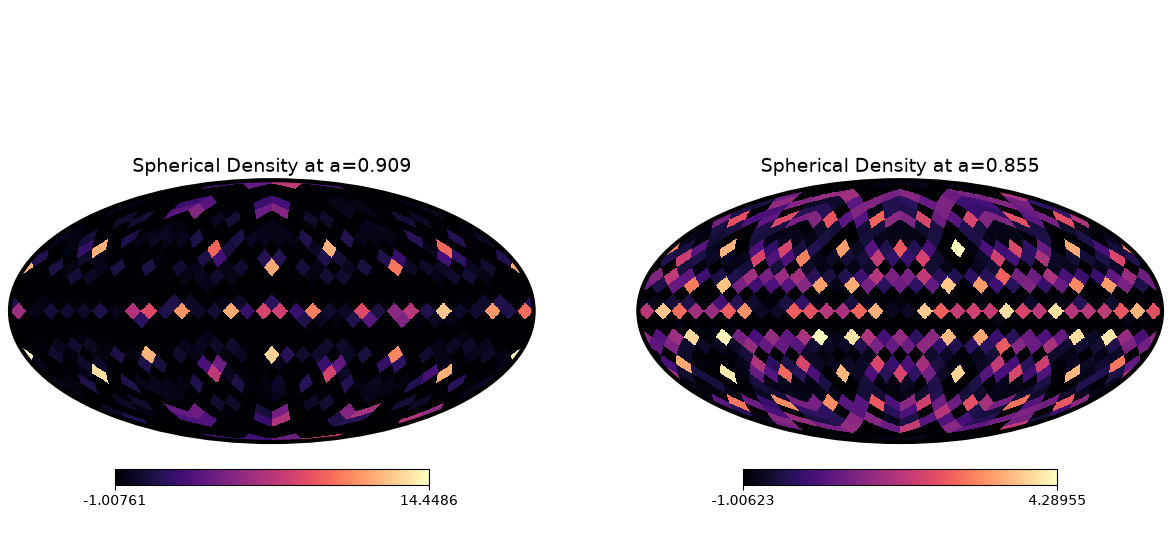

In [3]:
tr = trace(seed(model, SEED)).get_trace()

theta_truth_base = jnp.array([float(tr["Omega_c_base"]["value"]), float(tr["sigma8_base"]["value"])])
theta_truth = jnp.array([float(tr["Omega_c"]["value"]), float(tr["sigma8"]["value"])])
ic_truth_white = np.asarray(tr["initial_conditions"]["value"].array)
truth_cosmo = tr["cosmo"]["value"]

# Physical truth IC (white field coloured at the truth cosmology), for the section-9 comparison.
ic_truth = interpolate_initial_conditions(
    tr["initial_conditions"]["value"].array, config.mesh_size, config.box_size, cosmo=truth_cosmo
)

x_obs = jnp.stack([tr[f"observable_{i}"]["value"] for i in range(2)])
sig_obs = float(jnp.mean(tr["observable_0"]["fn"].scale))
snr = float(np.asarray(tr["observable_0"]["fn"].loc).std()) / sig_obs
print(f"truth  Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}   S/N per pixel ~ {snr:.1f}")

x_obs_field = jfli.SphericalDensity.FromDensityMetadata(array=x_obs, field=tr["observable_meta_data"]["value"])
x_obs_field.show()

## 4. Condition on observable

Free sites after conditioning: `Omega_c_base`, `sigma8_base`, `initial_conditions`.

In [4]:
cond_model = condition(model, data={f"observable_{i}": x_obs[i] for i in range(2)})

## 5. Make potential

`potential_fn(position)` is the NumPyro negative log posterior over the free sites.

In [5]:
param_info, potential_fn, postprocess_fn, _ = initialize_model(jax.random.PRNGKey(0), cond_model, dynamic_args=False)
init_params = param_info.z  # numpyro >= 0.21 wraps the position in a ParamInfo namedtuple
print("free sites:", list(init_params.keys()))

potential = lambda params: potential_fn(params)
vg = jax.jit(jax.value_and_grad(potential))

truth_position = {
    "Omega_c_base": theta_truth_base[0],
    "sigma8_base": theta_truth_base[1],
    "initial_conditions": jnp.asarray(ic_truth_white),
}
val, g = jax.block_until_ready(vg(truth_position))
assert np.isfinite(float(val)) and all(np.all(np.isfinite(np.asarray(x))) for x in jax.tree.leaves(g))
print(f"potential(truth) = {float(val):.2f}   (finite gradient OK)")

free sites: ['Omega_c_base', 'sigma8_base', 'initial_conditions']


potential(truth) = -6432.52   (finite gradient OK)


## 6. Minimize it

Warm start at the truth plus an `INIT_NOISE` perturbation, so the run isolates optimiser behaviour near the minimum. cadre stops on the objective/step tolerance, **not** the gradient — `|grad|` at the returned point is the convergence gate.

In [6]:
keys = jax.random.split(jax.random.PRNGKey(30), 3)
warm = {k: v + INIT_NOISE * jax.random.normal(keys[i], v.shape) for i, (k, v) in enumerate(truth_position.items())}

t0 = time.time()
map_params, state = cadre.minimize(
    potential,
    warm,
    solver_name="optax_lbfgs",
    max_iter=MAP_MAX_ITER,
    rtol=1e-8,
    atol=1e-8,
    record_history=True,  # per-step loss + update norm -> state.history
    precondition=False,  # True enables cadre's diagonal preconditioner
)
print(
    f"cadre optax_lbfgs: {int(state.iter_num)} steps in {time.time() - t0:.1f}s   best_loss={float(state.best_loss):.4f}"
)

_, g_map = vg(map_params)
gnorm = float(jnp.sqrt(sum(jnp.vdot(v, v).real for v in jax.tree.leaves(g_map))))
theta_map = phys_of_base(jnp.array([map_params["Omega_c_base"], map_params["sigma8_base"]]))
print(f"MAP   Omega_c={float(theta_map[0]):.4f}  sigma8={float(theta_map[1]):.4f}   |grad|={gnorm:.2e}")
print(f"truth Omega_c={float(theta_truth[0]):.4f}  sigma8={float(theta_truth[1]):.4f}")

0.00%|          | [00:00<?, ?%/s]

50.00%|█████     | [00:16<00:16,  2.97%/s]

50.00%|█████     | [00:16<00:16,  2.97%/s]

100.00%|██████████| [00:33<00:00,  2.99%/s]

100.00%|██████████| [00:33<00:00,  2.99%/s]

cadre optax_lbfgs: 2 steps in 73.5s   best_loss=-6395.9117


MAP   Omega_c=0.1322  sigma8=0.8683   |grad|=2.11e+04
truth Omega_c=0.1322  sigma8=0.8685


## 7. Loss and update curve

`state.history` is a `(2, max_iter)` table: row 0 is the per-step update norm, row 1 the objective at the *start* of that step — so the converged value is `state.best_loss`, not the last history entry.

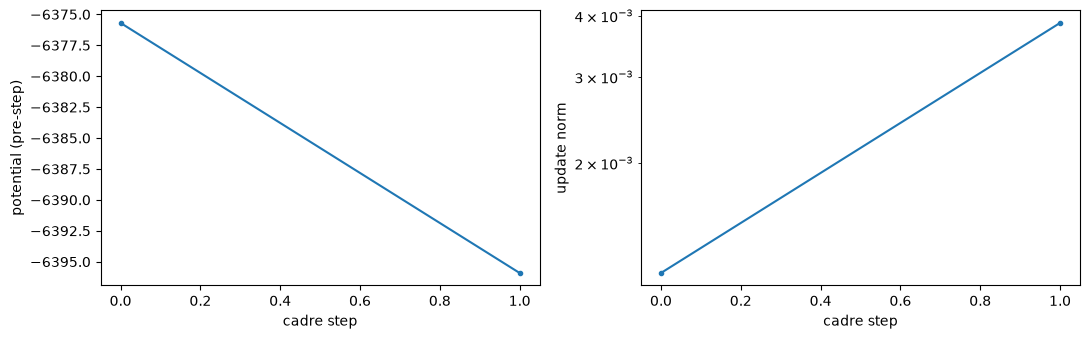

final converged objective (state.best_loss) = -6395.911677


In [7]:
hist = np.asarray(state.history)[:, : int(state.iter_num)]
steps = np.arange(hist.shape[1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ax1.plot(steps, hist[1], ".-")
ax1.set_xlabel("cadre step")
ax1.set_ylabel("potential (pre-step)")
ax2.plot(steps, hist[0], ".-")
ax2.set_xlabel("cadre step")
ax2.set_ylabel("update norm")
ax2.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"final converged objective (state.best_loss) = {float(state.best_loss):.6f}")

## 8. Uncertainty: Hessian of the conditioned potential

Conditioning **additionally** on the IC field at its MAP value leaves only the two base cosmology parameters free, so the Hessian of that potential is a cheap 2×2. This is a *conditional* covariance (IC fixed at the MAP), not the marginal over the field — marginalizing the field needs matrix-free curvature or MUSE. If second-order AD breaks through `jax_cosmo`'s custom VJPs, we fall back to central finite differences of the gradient (4 gradient evals for 2 parameters).

In [8]:
cond_ic = condition(
    model,
    data={
        "observable_0": x_obs[0],
        "observable_1": x_obs[1],
        "initial_conditions": map_params["initial_conditions"],
    },
)
_, pot2_fn, _, _ = initialize_model(jax.random.PRNGKey(0), cond_ic, dynamic_args=False)


def pot2(theta_base):
    return pot2_fn({"Omega_c_base": theta_base[0], "sigma8_base": theta_base[1]})


theta0 = jnp.array([float(map_params["Omega_c_base"]), float(map_params["sigma8_base"])])

# Hessian via reverse-mode autodiff twice (jacrev of grad)
# custom_vjp functions don't support forward-mode jvp, so we avoid jax.hessian
H = jax.jacrev(jax.grad(pot2))(theta0)
uq_method = "jax.jacrev(jax.grad)"

H = (H + H.T) / 2  # ensure symmetry
cov_base = jnp.linalg.inv(H)
sd_base = jnp.sqrt(jnp.diag(cov_base))
rho = float(cov_base[0, 1] / (sd_base[0] * sd_base[1]))

# base-space sigma -> physical space through the probit Jacobian d(phys)/d(base); rho is invariant.
jacobian = (HIGH - LOW) * jnp.exp(-0.5 * theta0**2) / jnp.sqrt(2 * jnp.pi)
sd_phys = jacobian * sd_base
print(f"UQ via {uq_method}:")
print(f"  sigma(Omega_c) = {float(sd_phys[0]):.3e}   sigma(sigma8) = {float(sd_phys[1]):.3e}   rho = {rho:.3f}")

jax.hessian failed (NotImplementedError: Differentiation rule for 'spmd_fft' not implemented)
-> fallback: central finite differences of the gradient


UQ via finite differences:
  sigma(Omega_c) = 3.502e-05   sigma(sigma8) = 2.321e-04   rho = 0.952


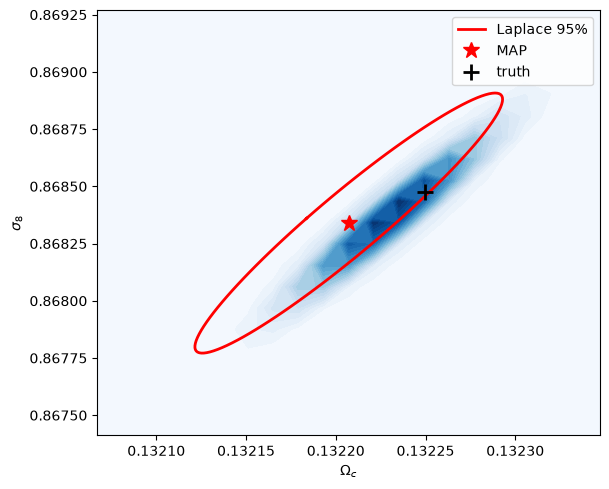

In [9]:
# Sanity check: exact 2D posterior on a small grid around the MAP (cheap forward evals at this
# mesh), with the Laplace ellipse mapped through the probit on top. If the red curve tracks the
# blue contours, the base-space Gaussian is a fair local approximation.
n_grid = 21
gx = float(theta_map[0]) + np.linspace(-4 * float(sd_phys[0]), 4 * float(sd_phys[0]), n_grid)
gy = float(theta_map[1]) + np.linspace(-4 * float(sd_phys[1]), 4 * float(sd_phys[1]), n_grid)
GX, GY = np.meshgrid(gx, gy)
pts = jnp.clip(jnp.asarray(np.stack([GX.ravel(), GY.ravel()], -1)), LOW, HIGH)
nll = np.asarray(jax.lax.map(lambda th: pot2(base_of_phys(th)), pts)).reshape(n_grid, n_grid)
nll = nll - nll.min()

t = np.linspace(0, 2 * np.pi, 120)
evals, evecs = np.linalg.eigh(np.asarray(cov_base))
ell_base = theta0[:, None] + evecs @ (
    np.sqrt(np.clip(5.991 * evals, 0.0, None))[:, None] * np.stack([np.cos(t), np.sin(t)], 0)
)
ell_phys = np.asarray(phys_of_base(ell_base.T))

fig, ax = plt.subplots(figsize=(6.2, 5))
ax.contourf(GX, GY, np.exp(-nll), 30, cmap="Blues")
ax.plot(ell_phys[:, 0], ell_phys[:, 1], "r-", lw=2, label="Laplace 95%")
ax.plot(float(theta_map[0]), float(theta_map[1]), "r*", ms=12, label="MAP")
ax.plot(float(theta_truth[0]), float(theta_truth[1]), "k+", ms=12, mew=2, label="truth")
ax.set_xlabel(r"$\Omega_c$")
ax.set_ylabel(r"$\sigma_8$")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Truth IC vs predicted IC

The MAP `initial_conditions` site is the *white* field; colouring it at the MAP cosmology gives the physical predicted IC, directly comparable with the truth IC from section 3.

IC recovery: MSE(truth, MAP) = 2.274e-08


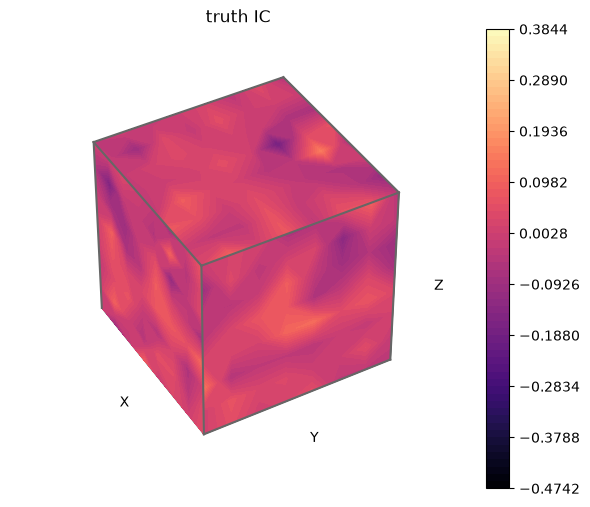

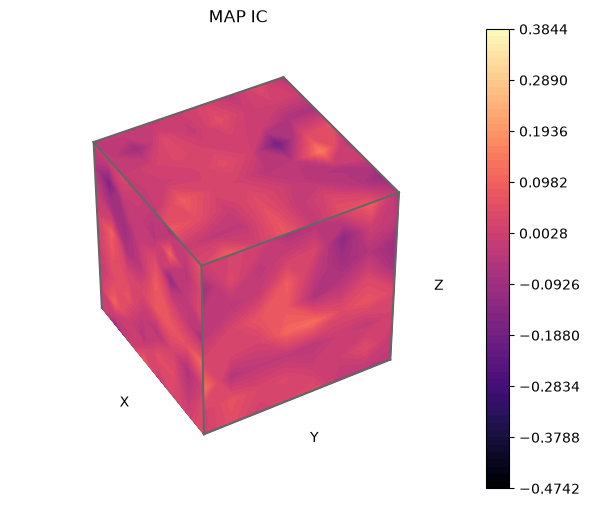

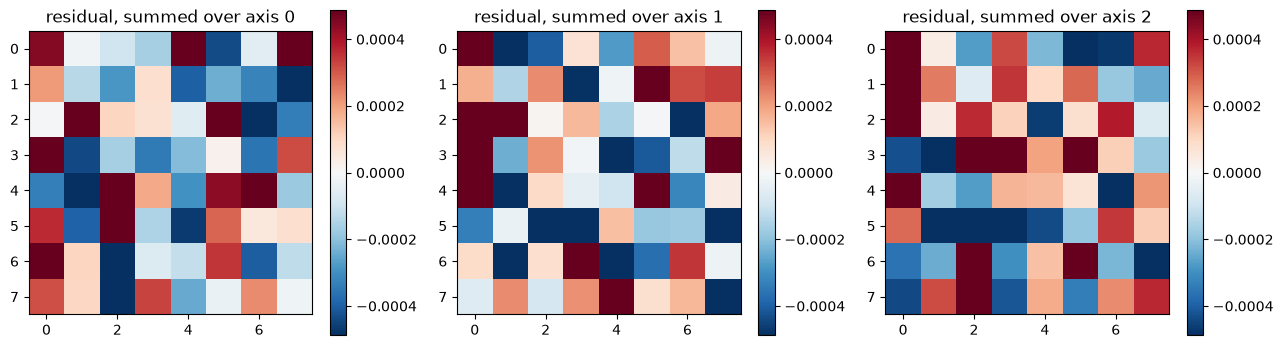

In [10]:
cosmo_map = config.fiducial_cosmology(Omega_c=float(theta_map[0]), sigma8=float(theta_map[1]))
ic_map = interpolate_initial_conditions(
    map_params["initial_conditions"], config.mesh_size, config.box_size, cosmo=cosmo_map
)

vmin = float(min(ic_truth.array.min(), ic_map.array.min()))
vmax = float(max(ic_truth.array.max(), ic_map.array.max()))
print(f"IC recovery: MSE(truth, MAP) = {float(((ic_truth.array - ic_map.array) ** 2).mean()):.3e}")

ic_truth.show(titles="truth IC", vmin=vmin, vmax=vmax)
ic_map.show(titles="MAP IC", vmin=vmin, vmax=vmax)

resid = np.asarray(ic_truth.array - ic_map.array)
m = float(np.abs(resid).max())
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for k, ax in enumerate(axes):
    im = ax.imshow(resid.sum(axis=k), cmap="RdBu_r", vmin=-m, vmax=m)
    ax.set_title(f"residual, summed over axis {k}")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()